# Hotel booking demand



#### Data Source: https://www.kaggle.com/jessemostipak/hotel-booking-demand

#### Data Description: The data is a record of hotel booking demand. It contains 32 columns and 119390 rows. The columns include information about the booking, the hotel, the customer, and the stay. The data is in a CSV file format.



## Project Overview
In this project, we aim to build a machine learning model to predict whether a hotel booking will be canceled (`is_canceled`). This prediction is crucial for hotels to manage resources efficiently and optimize revenue. By accurately predicting cancellations, hotels can take proactive measures such as overbooking or offering promotions to minimize the impact of cancellations.

**Data Loading and Exploration:(EDA)**
    - Load the dataset and explore its structure and contents.
    - Understand the features and target variable.

**Data Preprocessing:**
    - Handle missing values and outliers.
    - Encode categorical variables.
    - Normalize or scale numerical features if necessary.

**Feature Selection:**
    - Select relevant features that contribute to the prediction of cancellations.
    - Split the data into features (`X`) and target variable (`y`).

**Data Splitting:**
    - Split the data into training and testing sets to evaluate the models performance.

**Model Building:**
    - Choose appropriate machine learning algorithms.
    - Train the model using the training data.
    - Tune hyperparameters to improve model performance.

**Model Evaluation:**
    - Evaluate the model using the testing data.
    - Use metrics such as accuracy, precision, recall, and F1-score to assess the models performance.

**Model Interpretation:**
    - Interpret the models predictions and understand the importance of different features.
    - Visualize the results and insights gained from the model.

**Deployment:**
    - Deploy the model for real-time prediction if required.
    - Create a user interface or API for easy access to the models predictions.

By following these steps, we aim to develop a robust model that can help hotels make data-driven decisions to optimize their operations and minimize the impact of booking cancellations.


### Target
The target variable in this dataset is the `is_canceled` column. This column indicates whether a hotel booking was canceled or not. It is a binary variable with the following possible values:

- `0`: The booking was not canceled.
- `1`: The booking was canceled.

In [1]:
# import os
# os.environ['MPLBACKEND'] = 'agg'  # or 'tkagg'
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import seaborn as sns
import numpy as np


In [2]:

# Load the data
df = pd.read_csv('hotel_bookings.csv')

# Display the first few rows of the dataframe
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
#info about the data
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [4]:
# Divide the features into numerical and categorical types
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()


print("Numerical Features (Total: {}):".format(len(numerical_features)))
print(numerical_features)
print("\nCategorical Features (Total: {}):".format(len(categorical_features)))
print(categorical_features)

Numerical Features (Total: 20):
['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical Features (Total: 12):
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


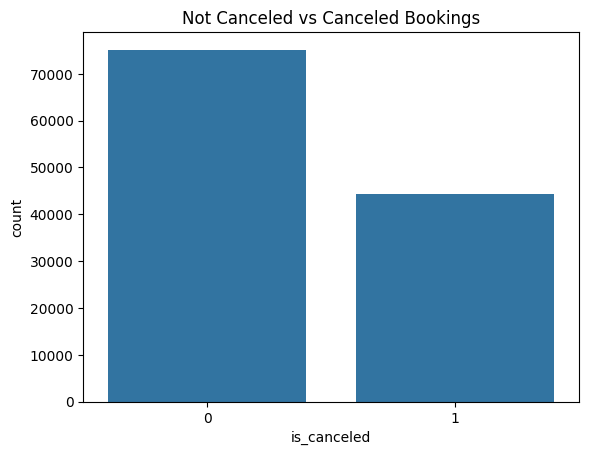

44224 Canceled (37.04%)
75166 Not Canceled (62.96%)


In [5]:
# Calculate the number of canceled and not canceled bookings
canceled = len(df[df["is_canceled"] == 1])
not_canceled = len(df[df["is_canceled"] == 0])
total = len(df)

# Plot the count of canceled vs not canceled bookings
sns.countplot(data=df, x="is_canceled")
plt.title("Not Canceled vs Canceled Bookings")
plt.show()

# Print the counts and percentages
print(f"{canceled} Canceled ({round(canceled / total * 100, 2)}%)")
print(f"{not_canceled} Not Canceled ({round(not_canceled / total * 100, 2)}%)")

In [6]:
# %pip install setuptools

In [7]:
# from ydata_profiling import ProfileReport

# # Assuming df is already defined
# design_report = ProfileReport(df)
# design_report.to_file(output_file='Hotel_Booking_Auto.html')

In [8]:

# import sweetviz as sv
# sweet_report = sv.analyze(df)
# sweet_report.show_html('Hotel_Booking_.html')

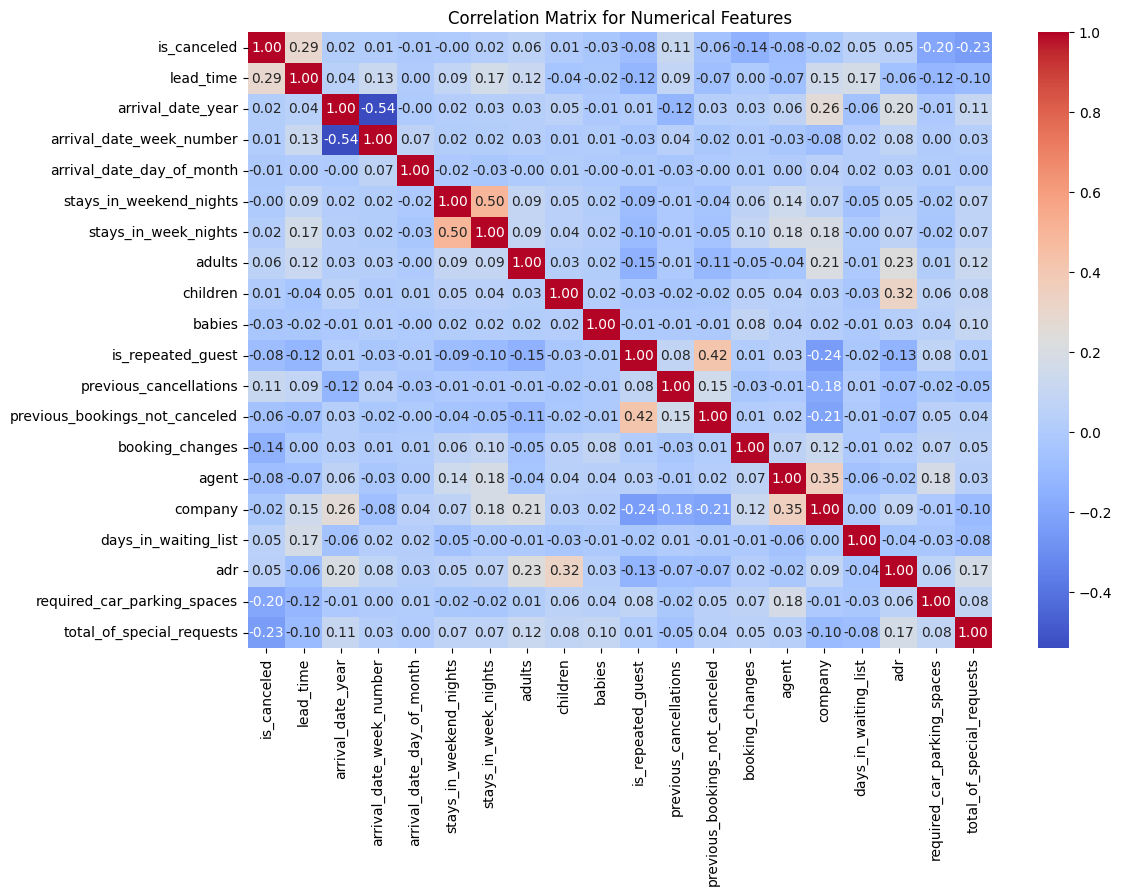

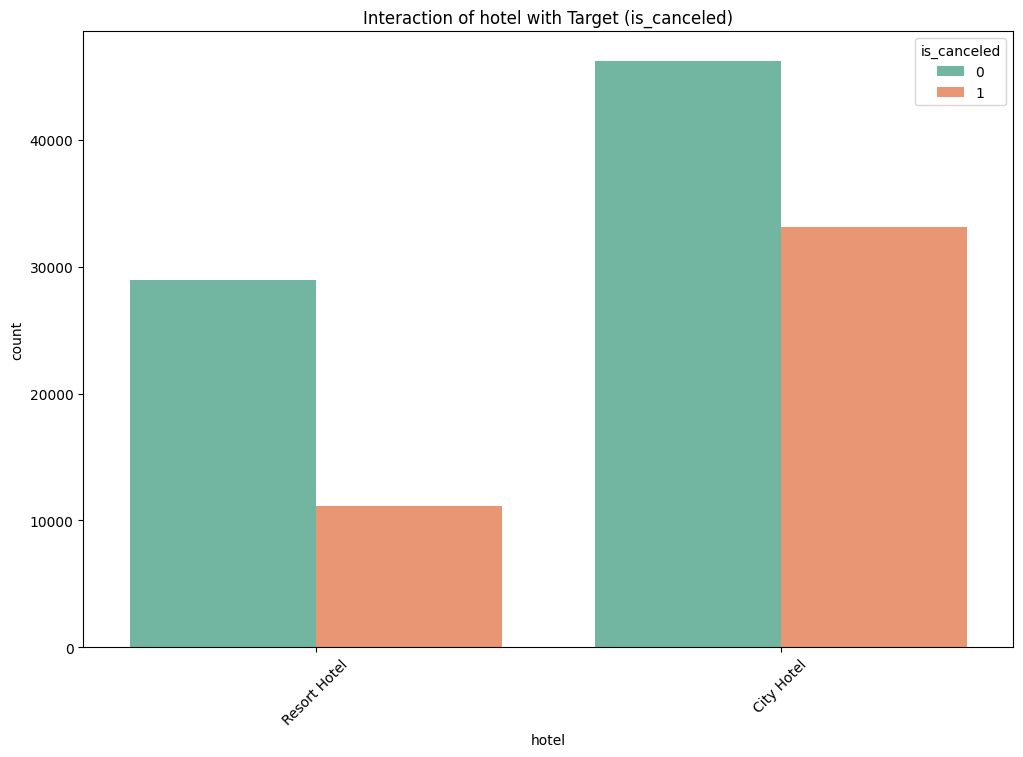

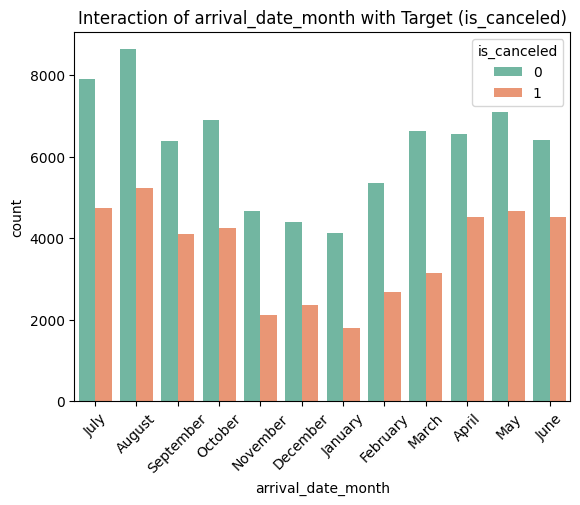

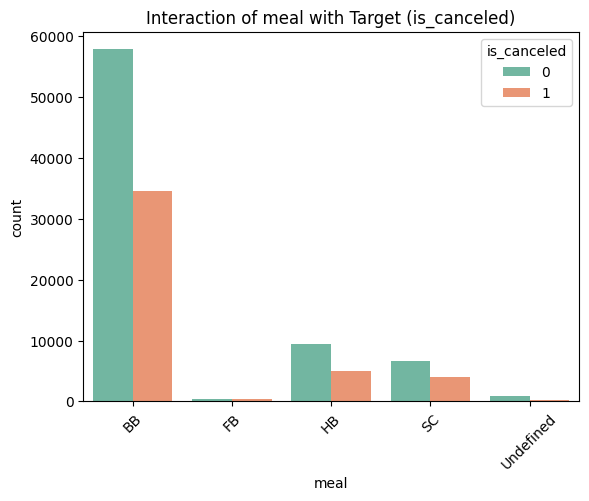

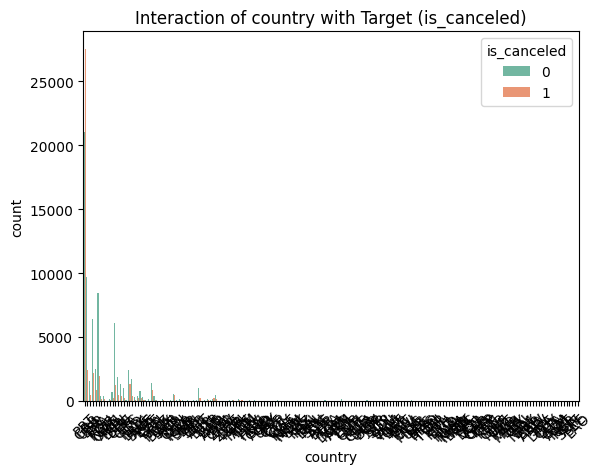

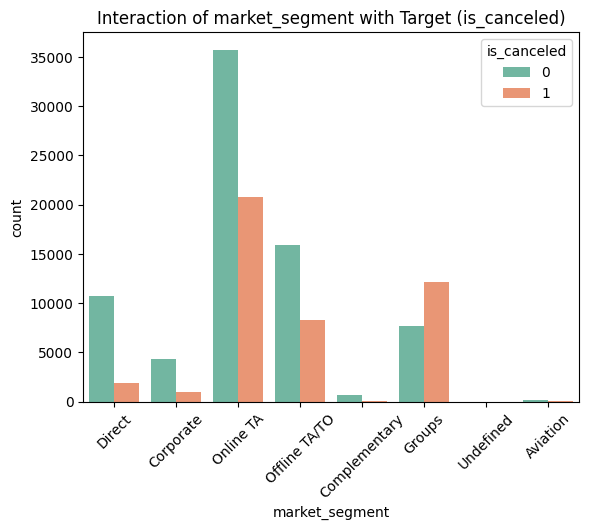

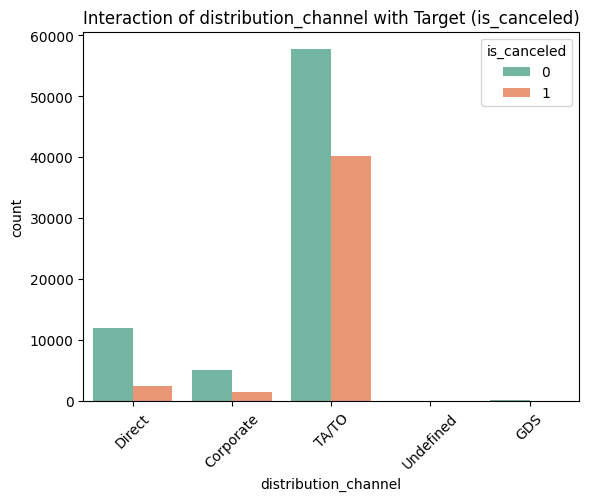

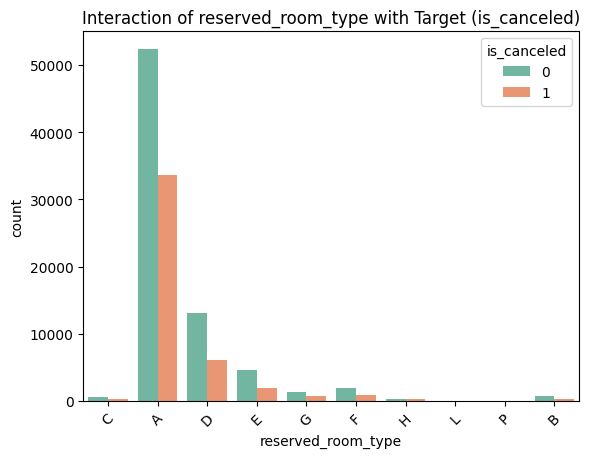

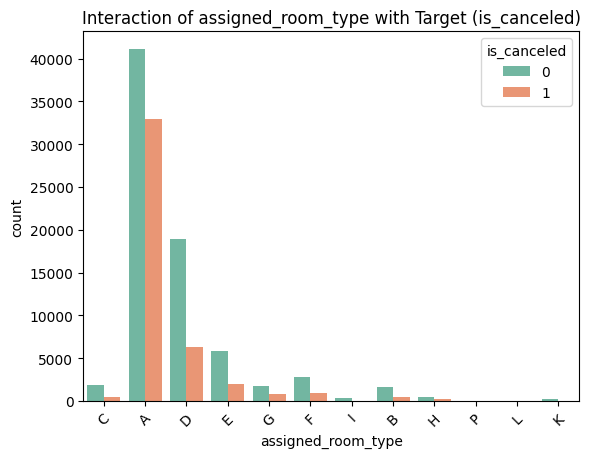

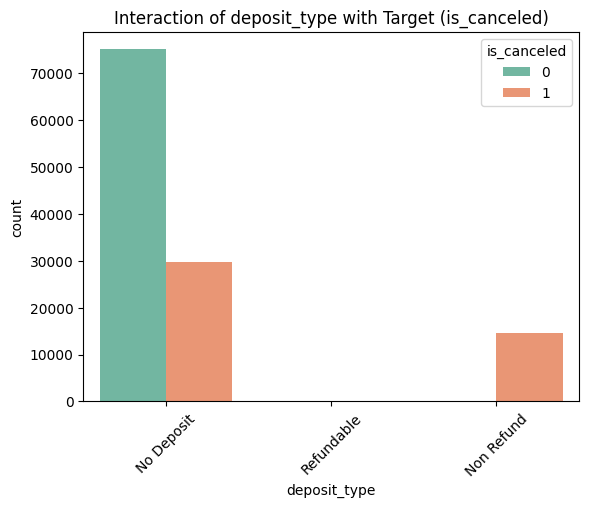

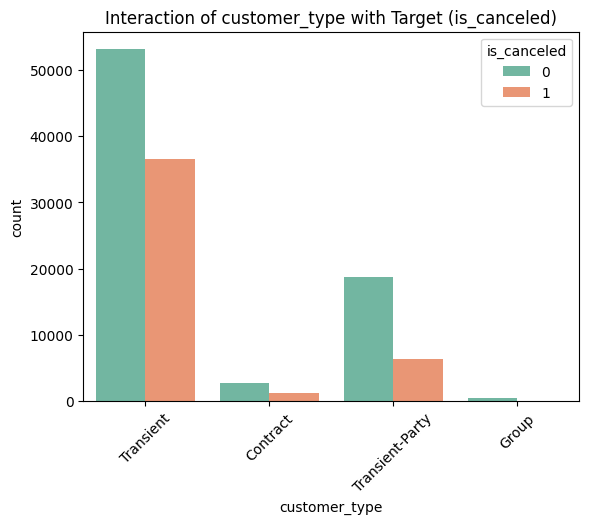

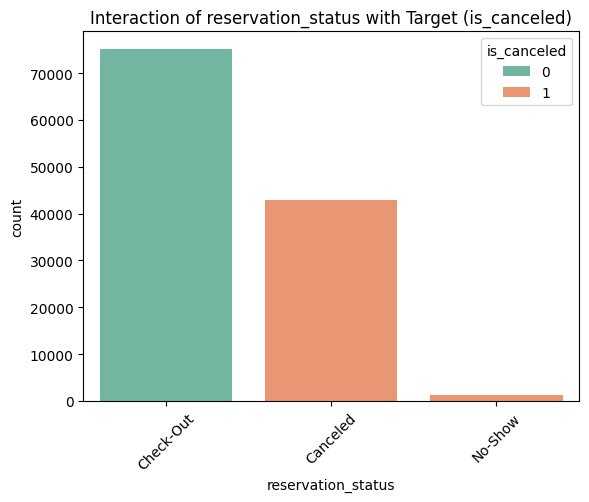

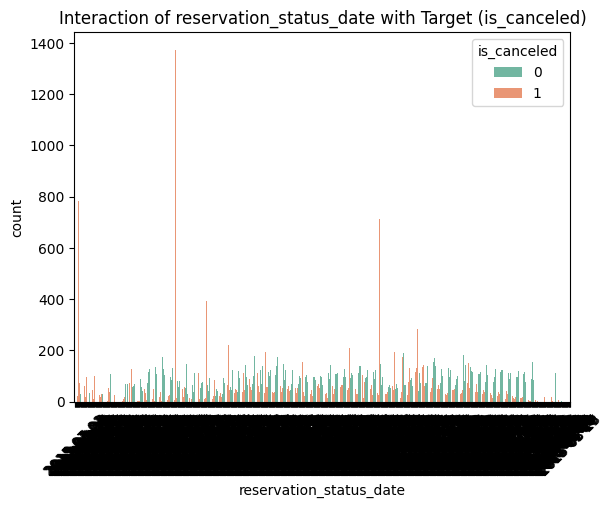

In [9]:
# Correlation matrix for numerical features
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix for Numerical Features")
plt.show()

# Interaction between categorical features
plt.figure(figsize=(12, 8))
for feature in categorical_features:
    sns.countplot(data=df, x=feature, hue="is_canceled", palette="Set2")
    plt.title(f"Interaction of {feature} with Target (is_canceled)")
    plt.xticks(rotation=45)
    plt.show()

To analyze the interactions and correlations, we can derive the following insights:

1. **Correlation Insights**:
    - The `correlation_matrix` shows how numerical features are related to each other and to the target variable (`is_canceled`).
    - Features like `lead_time` (0.293), `previous_cancellations` (0.110), and `total_of_special_requests` (-0.234) have notable correlations with `is_canceled`. This suggests that longer lead times and previous cancellations increase the likelihood of cancellation, while more special requests reduce it.
    - Features like `required_car_parking_spaces` (-0.195) and `booking_changes` (-0.144) also show moderate negative correlations with cancellations.

2. **Interaction Insights**:
    - The interaction plots between categorical features and `is_canceled` (e.g., `hotel`, `meal`, `market_segment`) reveal patterns in cancellation behavior.
    - For example, certain `market_segment` categories (like `Online TA`) may have higher cancellation rates compared to others (like `Corporate`).
    - Similarly, `deposit_type` interactions may show that bookings with no deposit are more likely to be canceled.



### Missing

In [10]:
# Calculate the number and percentage of missing values for each column
missing_values = df.isnull().sum()
missing_values_percentage = (missing_values / len(df)) * 100

# Create a DataFrame to display the missing values and their percentages
missing_values_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_values_percentage
}).sort_values(by='Missing Values', ascending=False)

# Display the table
missing_values_df = missing_values_df[missing_values_df['Missing Values'] > 0]
missing_values_df

,Missing Values,Percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350



### Insights from Missing Values

1. **Children**:
    - Only 4 missing values (0.003% of the total data).
    - This is negligible and can be handled by imputation (e.g., replacing with the median or mode).

2. **Country**:
    - 488 missing values (0.41% of the total data).
    - Although the percentage is small, imputing these values with the most frequent country or a placeholder like "Unknown" can be considered.

3. **Agent**:
    - 16,340 missing values (13.69% of the total data).
    - This is a significant proportion. Missing values could indicate direct bookings or unknown agents. A placeholder value (e.g., 0 or "Unknown") might be appropriate.

4. **Company**:
    - 112,593 missing values (94.31% of the total data).
    - The majority of bookings lack company information, likely because they are individual bookings. This column may not be useful for modeling and could be dropped or treated as a categorical feature with a placeholder value.

### Recommendations:
- Handle missing values based on their proportion and relevance to the analysis.
- Columns with a high percentage of missing values (e.g., `company`) should be carefully evaluated for their importance in the model.
```

In [11]:
# Handle missing values for 'children' (replace with median)
df['children'].fillna(df['children'].median(), inplace=True)

# Handle missing values for 'country' (replace with 'Unknown')
df['country'].fillna('Unknown', inplace=True)

# Handle missing values for 'agent' (replace with 0, assuming it indicates direct bookings)
df['agent'].fillna(0, inplace=True)

# Drop the 'company' column due to a high percentage of missing values
df.drop(columns=['company'], inplace=True)

# Verify the changes
print(df.isnull().sum())


hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

C:\Users\eitank\AppData\Local\Temp\ipykernel_23796\2896491457.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['children'].fillna(df['children'].median(), inplace=True)
C:\Users\eitank\AppData\Local\Temp\ipykernel_23796\2896491457.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

In [12]:
numerical_features.remove('company')


### Outliers

,Feature,Number of Outliers,Percentage
7,adults,29710,24.884831
13,booking_changes,18076,15.140297
8,children,8590,7.194907
17,required_car_parking_spaces,7416,6.211576
11,previous_cancellations,6484,5.430941
10,is_repeated_guest,3810,3.191222
16,adr,3793,3.176983
15,days_in_waiting_list,3698,3.097412
12,previous_bookings_not_canceled,3620,3.032080
6,stays_in_week_nights,3354,2.809281


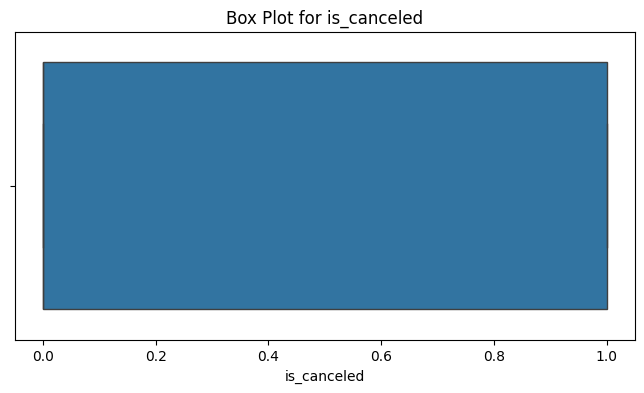

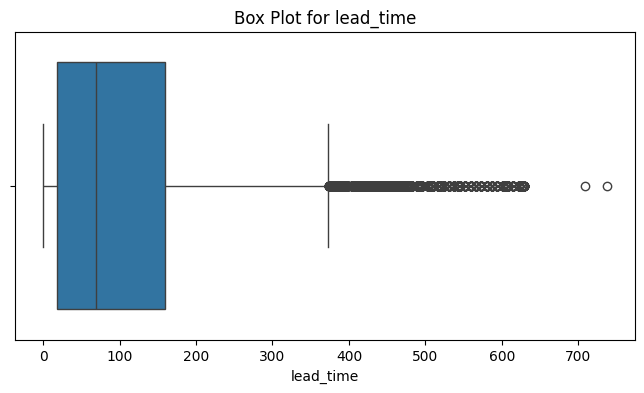

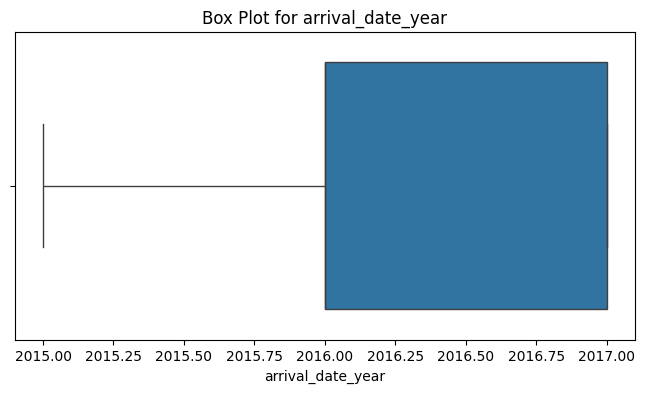

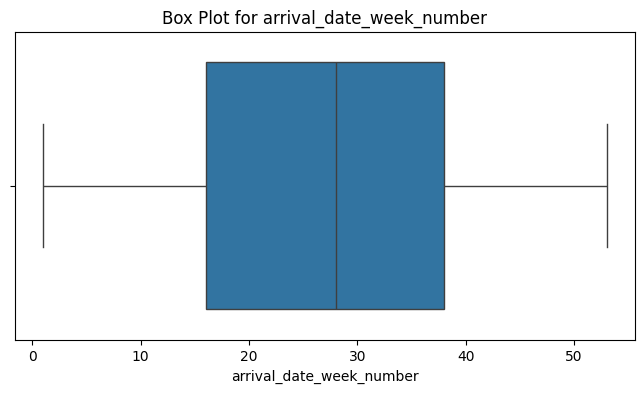

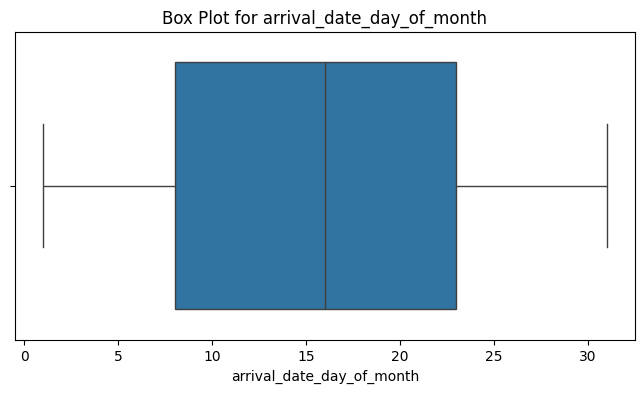

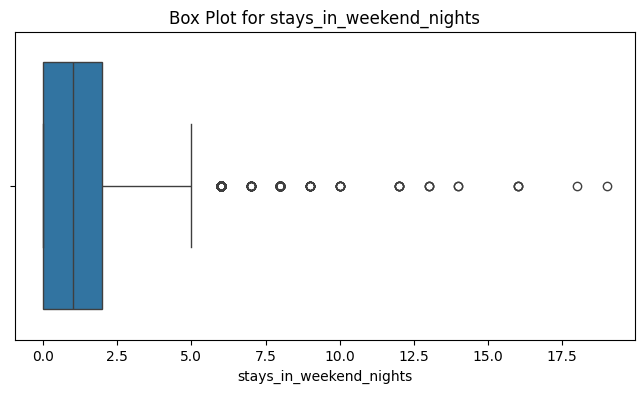

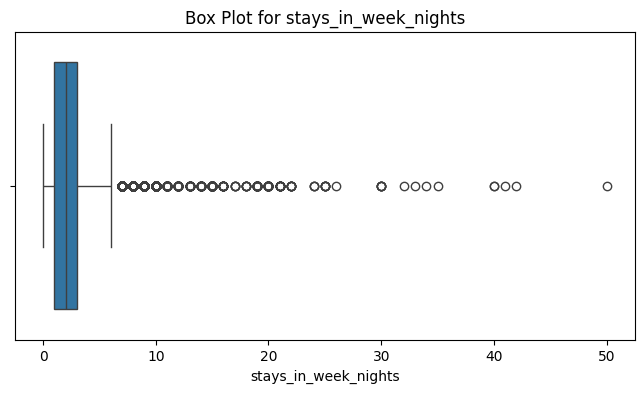

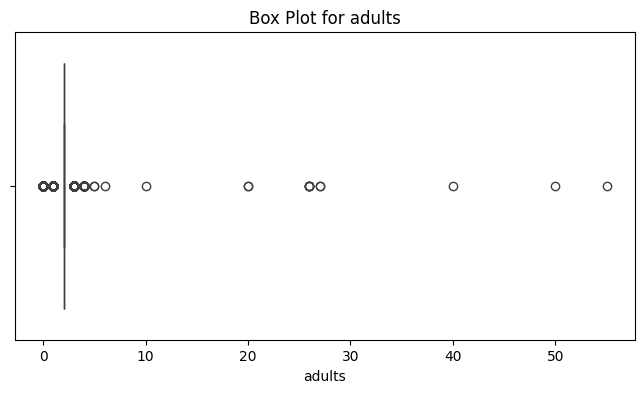

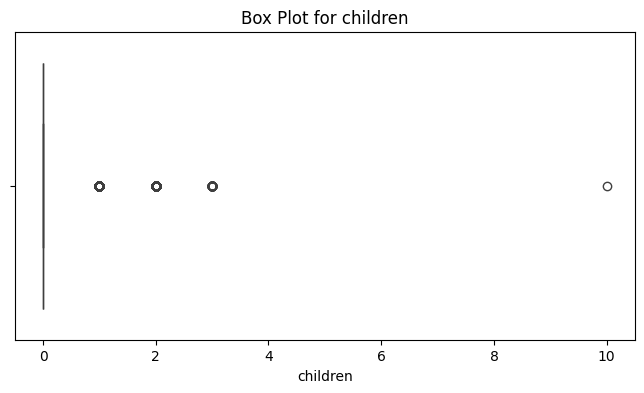

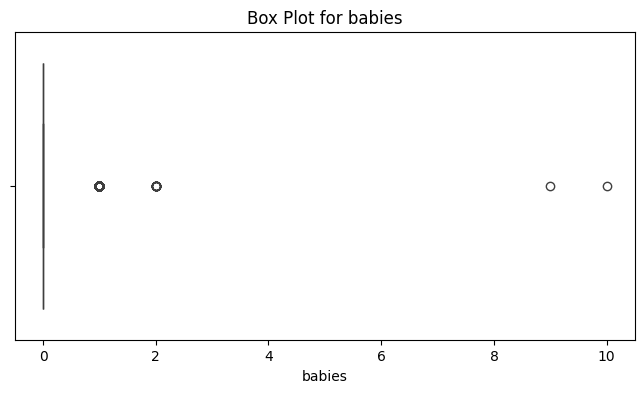

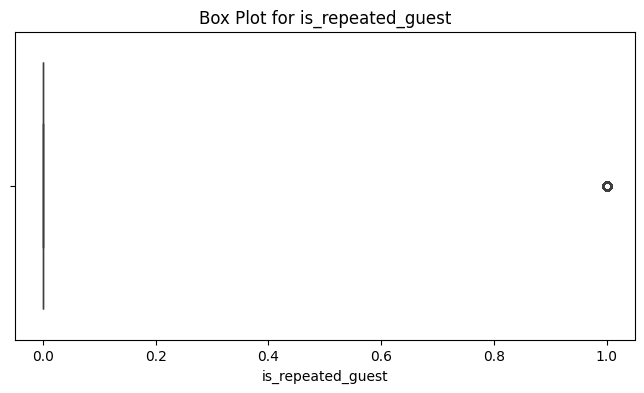

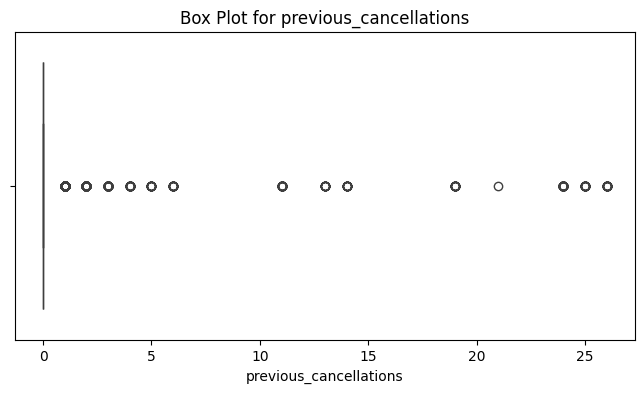

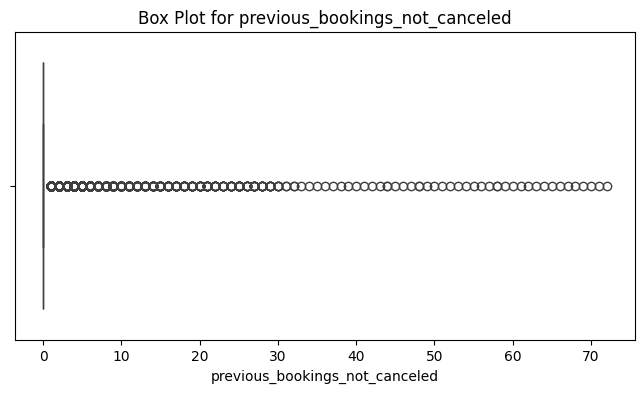

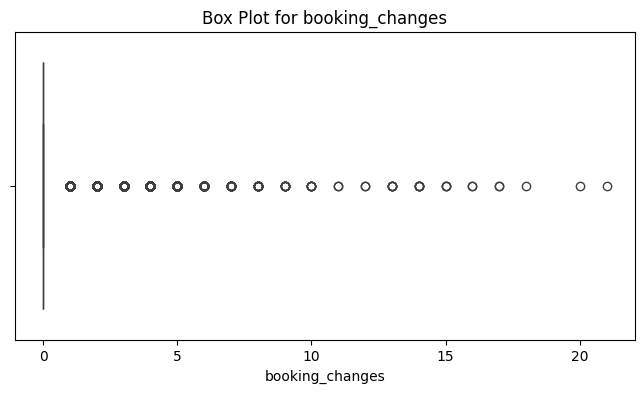

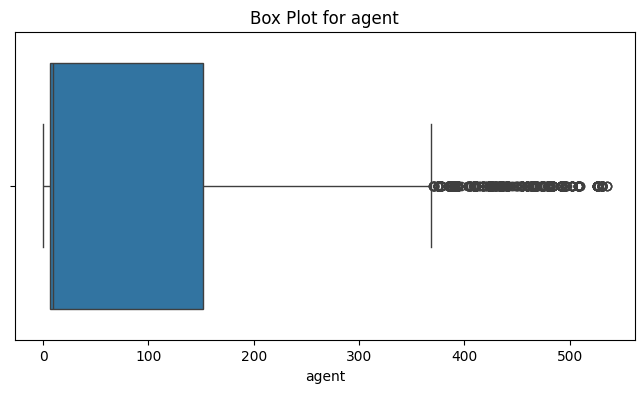

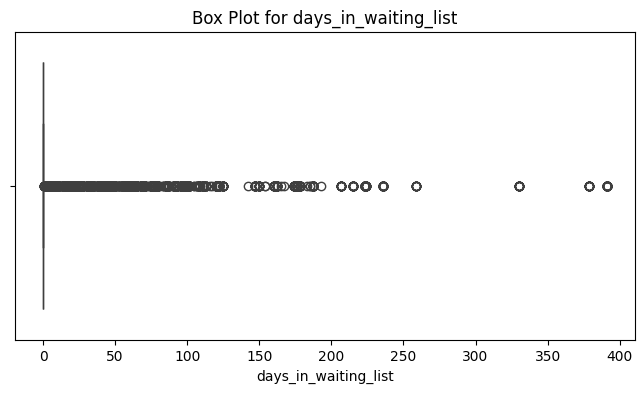

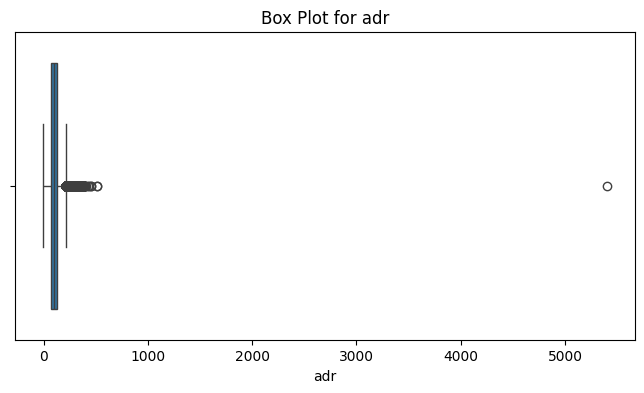

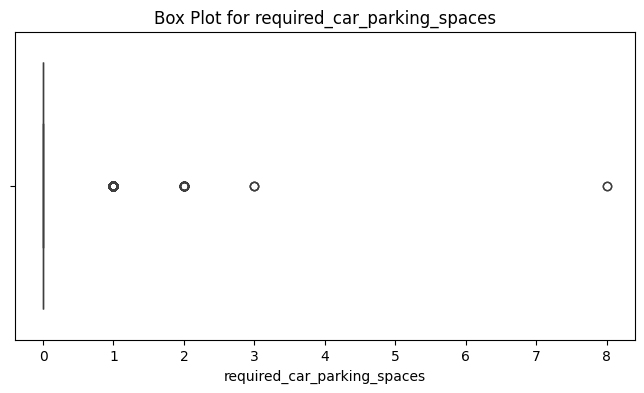

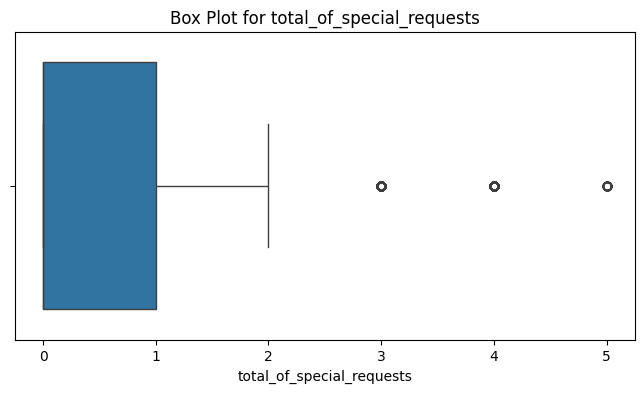

In [ ]:
# Identify and handle outliers in numerical features

# Identify outliers in numerical features using the IQR method
outliers_summary = []
for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    outliers_count = len(outliers)
    outliers_percentage = outliers_count / len(df) * 100

    outliers_summary.append({
        'Feature': feature,
        'Number of Outliers': outliers_count,
        'Percentage': outliers_percentage
    })

# Convert the summary to a DataFrame for better visualization
outliers_summary_df = pd.DataFrame(outliers_summary).sort_values(by='Number of Outliers', ascending=False)

# Display the summary
display(outliers_summary_df.style.set_caption("Outliers Summary"))

# Visualize outliers using box plots
for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=feature)
    plt.title(f"Box Plot for {feature}")
    plt.show()



In [14]:
# Handle outliers for each numerical feature
for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # For features with a high percentage of outliers, cap the values
    if feature in ['adults', 'children', 'adr', 'lead_time']:
        df[feature] = np.where(df[feature] < lower_bound, lower_bound, df[feature])
        df[feature] = np.where(df[feature] > upper_bound, upper_bound, df[feature])
    # For features with a moderate percentage of outliers, remove the rows
    elif feature in ['stays_in_weekend_nights', 'stays_in_week_nights', 'total_of_special_requests']:
        df = df[(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]
    # For features with very few outliers, leave them as is
    else:
        pass

# Verify the changes
print("Number of rows after handling outliers:", len(df))

Number of rows after handling outliers: 113268


In [1]:
# Visualize the distribution of numerical features after handling outliers
for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=feature, bins=30, kde=True)
    plt.title(f"Distribution of {feature} After Handling Outliers")
    plt.show()

NameError: name 'numerical_features' is not defined